In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,average_precision_score,confusion_matrix,roc_curve,ConfusionMatrixDisplay,RocCurveDisplay,balanced_accuracy_score
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [18]:
ml_labels = pd.read_csv("/Users/eric/repos/aud/ml/ml_labels_90.csv")
ml_labels.head()

,subid,day,day_of_week_num_0,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,latest_ema_2,latest_ema_3,latest_ema_4,latest_ema_5,latest_ema_6,latest_ema_7,latest_ema_8,latest_ema_9,latest_ema_10,srm_ema_2,srm_ema_3,srm_ema_4,srm_ema_5,srm_ema_6,srm_ema_7,srm_ema_8,srm_ema_9,srm_ema_10,lrm_ema_2,lrm_ema_3,lrm_ema_4,lrm_ema_5,lrm_ema_6,lrm_ema_7,lrm_ema_8,lrm_ema_9,lrm_ema_10,recent_lapse_1,recent_lapse_3,recent_lapse_5,lapse_w0,lapse_w1,lapse_w3,lapse_w7
0,1,0,0,0,0,1,0,0,0,0.333333,1.000000,1.000000,0.666667,0.5,0.7,0.4,0.4,0.3,0.333333,1.000000,1.000000,0.666667,0.500000,0.700000,0.400000,0.4,0.3,0.333333,1.000000,1.000000,0.666667,0.50,0.700000,0.400000,0.400,0.3,False,False,False,0,0.0,0.0,0.0
1,1,1,0,0,0,0,1,0,0,0.166667,0.333333,0.333333,0.666667,0.5,0.2,0.4,0.6,0.3,0.250000,0.666667,0.666667,0.666667,0.500000,0.450000,0.400000,0.5,0.3,0.250000,0.666667,0.666667,0.666667,0.50,0.450000,0.400000,0.500,0.3,False,False,False,0,0.0,0.0,0.0
2,1,2,0,0,0,0,0,1,0,0.166667,0.333333,0.333333,0.666667,0.5,0.2,0.4,0.6,0.3,0.250000,0.666667,0.666667,0.666667,0.500000,0.450000,0.400000,0.5,0.3,0.250000,0.666667,0.666667,0.666667,0.50,0.450000,0.400000,0.500,0.3,False,False,False,0,0.0,0.0,0.0
3,1,3,0,0,0,0,0,0,1,0.166667,0.000000,0.000000,0.416667,0.5,0.2,0.3,0.5,0.3,0.222222,0.444444,0.444444,0.583333,0.500000,0.366667,0.366667,0.5,0.3,0.222222,0.444444,0.444444,0.583333,0.50,0.366667,0.366667,0.500,0.3,False,False,False,0,0.0,0.0,0.0
4,1,4,1,0,0,0,0,0,0,0.166667,0.083333,0.333333,0.666667,0.7,0.7,0.6,0.4,0.3,0.166667,0.138889,0.222222,0.583333,0.566667,0.366667,0.433333,0.5,0.3,0.208333,0.354167,0.416667,0.604167,0.55,0.450000,0.425000,0.475,0.3,False,False,False,0,0.0,0.0,0.0


In [7]:
ml_labels.shape
ml_labels.lapse_w0.sum()/ml_labels.shape[0]

0.07548520521794463

In [19]:
subject_info = pd.read_csv('/Users/eric/repos/aud/data/subject_info.csv')
included_subids = subject_info.query("responsiveness>=0.25").subid.unique()
excluded_subids = subject_info.query("responsiveness < 0.25").subid.unique()
print("excluded:",excluded_subids)
print("included count:",len(included_subids))
subject_info.head()

excluded: [ 80 193 232]
included count: 148


,subid,mema_count,last_morning_ema_day,first_morning_ema_day,responsiveness
0,1,64,89,0,0.711111
1,2,77,84,0,0.905882
2,3,87,89,0,0.966667
3,5,90,91,0,0.988889
4,6,79,86,0,0.908046


In [ ]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
subinfo = subject_info.copy(deep=True)
subinfo.mema_count = subinfo.apply(lambda row: 90 if row.mema_count>90 else row.mema_count,axis=1)
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=subinfo,x='responsiveness',ax=ax,stat='proportion',binwidth=0.05,binrange=(0,1))
ax.set_xticks(np.arange(0,1.1,.1))
ax.set_xlabel('Fraction of study days with morning EMAs')
fig.savefig("plots/ema_missingness.pdf",bbox_inches='tight',facecolor='w')

(0.0, 0.55)

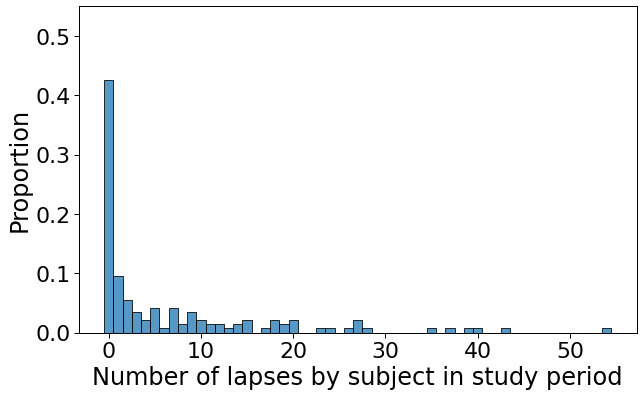

In [3]:
sns.set_context('paper',font_scale=2.5)
day_labels = pd.read_csv('/Users/eric/repos/aud/data/day_labels.csv')
day_labels.head()
lapse_sums = day_labels.query("subid in @included_subids").groupby("subid").lapse.sum()
lapse_sums.head()
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=lapse_sums,ax=ax,stat='proportion',discrete=True)
ax.set_xlabel("Number of lapses by subject in study period")
ax.set_yticks(np.arange(0,0.6,0.1))
ax.set_ylim((0,0.55))
#fig.savefig("plots/lapse_proportions.pdf",bbox_inches='tight',facecolor='w')

In [20]:
def ml_fit_study_day_col_adder(subid,day,subject_info):
    sub = subject_info.query("subid==@subid")
    first_ema = sub.iloc[0].first_morning_ema_day # note 0 indexed
    if first_ema == 0:
        return int(day)
    else:
        return int(day-first_ema)
    
def decode_key(row):
    key_str = row.key
    (split_str,rs_str,fold_str,id_str) = key_str.split('_')
    split = split_str[-1]
    rs = rs_str[-1]
    fold = fold_str[-1]
    id = id_str[-1]
    return {'split':split,'random_state':rs,'fold':fold,'id':id,'unique_fold':"{}_{}_{}".format(split_str,rs_str,fold_str)}

# 1690562 is the ML data efficiency run for 5foldCV (random state 1)
# 1691069 is the LOO case
# 1691084 is the ML data efficiency run for 10foldCV (random state 1)
# 1745273 is the ML data efficiency run for 5foldCV (random states 1-6) (errors)
# 1746158 is the ML data efficiency run for 5foldCV (random states 7-15) (errors)
run = 1690562
new_format = run>1572467
import_path = "/Users/eric/repos/aud/analysis/imports/"+str(run)

files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    df_list.append(iter_df)

#print(len(df_list))
ml_df = pd.concat(df_list,ignore_index=True)
print(ml_df.shape)
# The ML fits are done on zero-indexed data, need to add 1 to get to 1 indexing
ml_df.day = ml_df.day+1

ml_df['study_day'] = ml_df.apply(lambda row: ml_fit_study_day_col_adder(row.subid,row.day,subject_info),axis=1)

idxs = ml_df.query("study_day<train_width").index
mod_ml_df = ml_df.drop(index=idxs)
print(mod_ml_df.shape)
mod_ml_df[['split','random_state','fold','id','unique_fold']] = mod_ml_df.apply(lambda row: decode_key(row),axis='columns',result_type='expand')
mod_ml_df.head()

(486506, 8)
(231222, 9)


,subid,day,train_width,key,window,pred,act,fit_type,study_day,split,random_state,fold,id,unique_fold
14,2,15,15,split5_rs1_fold2_id0,0,0.066409,0.0,LR,15,5,1,2,0,split5_rs1_fold2
15,2,16,15,split5_rs1_fold2_id0,0,0.081356,0.0,LR,16,5,1,2,0,split5_rs1_fold2
16,2,17,15,split5_rs1_fold2_id0,0,0.022366,0.0,LR,17,5,1,2,0,split5_rs1_fold2
17,2,18,15,split5_rs1_fold2_id0,0,0.018219,0.0,LR,18,5,1,2,0,split5_rs1_fold2
18,2,19,15,split5_rs1_fold2_id0,0,0.020739,0.0,LR,19,5,1,2,0,split5_rs1_fold2


In [21]:
def ssm_fit_study_day_col_adder(subid,day,subject_info):
    sub = subject_info.query("subid==@subid")
    first_ema = sub.iloc[0].first_morning_ema_day # note 0 indexed
    if first_ema == 0:
        return int(day)
    else:
        return int(day-first_ema)
def key_fix(row):
    keyval = row.key
    return "split5_"+str(keyval)

# Rolling plots
# 1690561 gives the MAP runs for 15-step rolling evaluations of all individuals using 5fold CV (random state 1)
# 1691031 is a re-run of the previous case after minor code cleanup (5fold, random state 1)
# 1691067 is a LOO run
# 1691085 gives the MAP runs for 15-step rolling evaluations of all individuals using 10fold CV (random state 1)
# 1746386 is the MAP runs for 15-step rolling evals using 5fold CV (random state 1) - post truncnorm debugging, used as a test
# 1746731 is the MAP runs for 15-step rolling evals using 5fold CV (random states 1-15)
run = 1746386
import_path = "/Users/eric/repos/aud/analysis/imports/"+str(run)

files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    df_list.append(iter_df)

#print(len(df_list))
df = pd.concat(df_list,ignore_index=True)
print(df.shape)
df.head()

ssm_df = df[['subid','train_width','day','w0_pred','w0_act','w1_pred',
                  'w1_act','w3_pred','w3_act','w7_pred','w7_act','fit_type','key']]
ssm_df['study_day'] = ssm_df.apply(lambda row: ssm_fit_study_day_col_adder(row.subid,row.day,subject_info),axis="columns")
if run==1690561:
    ssm_df['key']=ssm_df.apply(lambda row: key_fix(row),axis=1)
ssm_df[['split','random_state','fold','id','unique_fold']] = ssm_df.apply(lambda row: decode_key(row),axis='columns',result_type='expand')
ssm_df.head()

(30850, 25)


/var/folders/yv/fz_ldjls7497yzp899r2yzw80000gn/T/ipykernel_6491/2368448151.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssm_df['study_day'] = ssm_df.apply(lambda row: ssm_fit_study_day_col_adder(row.subid,row.day,subject_info),axis="columns")
/var/folders/yv/fz_ldjls7497yzp899r2yzw80000gn/T/ipykernel_6491/2368448151.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssm_df[['split','random_state','fold','id','unique_fold']] = ssm_df.apply(lambda row: decode_key(row),axis='columns',result_type='exp

,subid,train_width,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type,key,study_day,split,random_state,fold,id,unique_fold
0,77,15,16,0.024255,0,0.053347,0.0,0.109808,0.0,0.213071,0.0,MAP_mle,split5_rs1_fold0_id77,15,5,1,0,7,split5_rs1_fold0
1,77,15,17,0.100217,0,0.166191,0.0,0.288722,0.0,0.495964,0.0,MAP_mle,split5_rs1_fold0_id77,16,5,1,0,7,split5_rs1_fold0
2,77,15,18,0.051234,0,0.116260,0.0,0.236566,0.0,0.448919,1.0,MAP_mle,split5_rs1_fold0_id77,17,5,1,0,7,split5_rs1_fold0
3,77,15,19,0.058614,0,0.088230,0.0,0.153764,0.0,0.277165,1.0,MAP_mle,split5_rs1_fold0_id77,18,5,1,0,7,split5_rs1_fold0
4,77,15,20,0.014167,0,0.044191,0.0,0.099009,0.0,0.207933,1.0,MAP_mle,split5_rs1_fold0_id77,19,5,1,0,7,split5_rs1_fold0


In [ ]:
# Imported sample data and wrote them out for easier access (skips processing stage)

# ssm_df.to_csv('test_ssm.csv',index=False)
# mod_ml_df.to_csv('test_ml.csv',index=False)

In [ ]:
# Read in sample data for easier debugging of day alignment
ssm_df = pd.read_csv("test_ssm.csv")
mod_ml_df = pd.read_csv('test_ml.csv')

# Modifications
ssm_drop_idxs = []
# Subid 191 day 85 width 15 (15 consecutive days with no entries)
gather_drop_df = ssm_df.query("train_width==15 & subid==191 & day==85")
ssm_drop_idxs.extend(gather_drop_df.index.tolist())
# Subid 207 days 77-87 width 15 (all such days have 15 consecutive days with no entries)
problem_days = [77,78,79,80,81,82,83,84,85,86,87]
gather_drop_df = ssm_df.query("train_width==15 & subid==207 & day in @problem_days")
ssm_drop_idxs.extend(gather_drop_df.index.tolist())
# Subid 66 day 80 width 15 (15 consecutive days with no entries)
gather_drop_df = ssm_df.query("train_width==15 & subid==66 & day==80")
ssm_drop_idxs.extend(gather_drop_df.index.tolist())
# Drop them
ssm_df.drop(index=ssm_drop_idxs,inplace=True)
print(ssm_drop_idxs)

In [ ]:
ssm_df.head()

In [ ]:
mod_ml_df.head()

In [ ]:
# Debugging import ML days
day_labels = pd.read_csv("/Users/eric/repos/aud/data/day_labels.csv")

In [ ]:
day_labels.query("subid==66")

In [8]:
# Check for differences in the days included in each dataframe
window_delta = [0,1,3,7]
train_widths = [15,30,45,60,75]
if not np.array_equal(np.unique(ssm_df.unique_fold),np.unique(mod_ml_df.unique_fold)):
    print("fold mismatch error, stopping")
    raise KeyboardInterrupt
unique_folds=np.unique(ssm_df.unique_fold)

for fold in unique_folds:
    ssm_iter_df = ssm_df.query("unique_fold==@fold")
    ml_iter_df = mod_ml_df.query("unique_fold==@fold")
    ssm_ids = np.unique(ssm_iter_df.subid)
    ml_ids = np.unique(ml_iter_df.subid)
    if not np.array_equal(ssm_ids,ml_ids):
        print("Error in fold {}, subids do not align between dataframes".format(fold))
        raise KeyboardInterrupt
    for width in train_widths:
        ssm_width_iter_df = ssm_iter_df.query("train_width==@width")
        ml_width_iter_df = ml_iter_df.query("train_width==@width")
        for id in ssm_ids:
            ssm_subject_iter_df = ssm_width_iter_df.query("subid==@id")
            ml_subject_iter_df = ml_width_iter_df.query("subid==@id")
            ssm_days = np.unique(ssm_subject_iter_df.day)
            ml_days = np.unique(ml_subject_iter_df.day)
            if not np.array_equal(ssm_days,ml_days):
                print("Error in fold {} subid {}, width {}, subids do not have the same study days".format(fold,id,width))
                raise KeyboardInterrupt
            for day in ssm_days:
                ssm_subject_day_iter_df = ssm_subject_iter_df.query("day==@day")
                if ssm_subject_day_iter_df.shape[0]!=1:
                    print("Error in fold {}, subid {}, day {}, SSM has too many/few entries".format(fold,id,day))
                    raise KeyboardInterrupt
                ml_subject_day_iter_df = ml_subject_iter_df.query("day==@day")
                for delta in window_delta:
                    # Need to rework starting here, issue is that rows exist for nan predictions in SSM, but do not in the ML one
                    ssm_str_pred = "w"+str(delta)+"_pred"
                    ssm_str_act = "w"+str(delta)+"_act"
                    ssm_pred = ssm_subject_day_iter_df.iloc[0][ssm_str_pred]
                    ssm_act = ssm_subject_day_iter_df.iloc[0][ssm_str_act]
                    lr_subject_day_window_iter_df = ml_subject_day_iter_df.query("window==@delta & fit_type=='LR'")
                    if lr_subject_day_window_iter_df.shape[0]==0:
                        lr_pred = np.nan
                        lr_act = np.nan
                    elif lr_subject_day_window_iter_df.shape[0]==1:
                        lr_pred = lr_subject_day_window_iter_df.iloc[0].pred
                        lr_act = lr_subject_day_window_iter_df.iloc[0].act
                    else:
                        print("Error in fold{}, subid {}, day {}, window {}, LR too many entries".format(fold,id,day,delta))
                        raise KeyboardInterrupt
                    xgb_subject_day_window_iter_df = ml_subject_day_iter_df.query("window==@delta & fit_type=='XGB'")
                    if xgb_subject_day_window_iter_df.shape[0]==0:
                        xgb_pred = np.nan
                        xgb_act = np.nan
                    elif xgb_subject_day_window_iter_df.shape[0]==1:
                        xgb_pred = xgb_subject_day_window_iter_df.iloc[0].pred
                        xgb_act = xgb_subject_day_window_iter_df.iloc[0].act
                    else:
                        print("Error in fold{}, subid {}, day {}, window {}, XGB too many entries".format(fold,id,day,delta))
                        raise KeyboardInterrupt
                    
                    # Final check
                    ssm_arr = np.array([np.isnan(ssm_pred),ssm_act])
                    lr_arr = np.array([np.isnan(lr_pred),lr_act])
                    xgb_arr = np.array([np.isnan(xgb_pred),xgb_act])
                    if not (np.array_equal(ssm_arr,lr_arr,equal_nan=True) and np.array_equal(lr_arr,xgb_arr,equal_nan=True)):
                        print("Error in fold{}, subid {}, day {}, window {}, entries do not match".format(fold,id,day,delta))
                        print(ssm_arr,lr_arr,xgb_arr)
                        raise KeyboardInterrupt

In [ ]:
ssm_df.query("day==84")

In [ ]:
mod_ml_df.query("subid==3 & day>=83 & train_width==15 & window==7")

In [22]:
# Cross fold evals (LOO not included here)

widths = [15,30,45,60,75]
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for width in widths:
        print(width)
        ssm_iter_df = ssm_df.query("train_width==@width & unique_fold!='splitLOO_'").copy(deep=True)
        ml_iter_df = mod_ml_df.query("train_width==@width & unique_fold!='LOO'")
        if not np.array_equal(np.unique(ssm_iter_df.unique_fold),np.unique(ml_iter_df.unique_fold)):
            print("fold mismatch error, stopping")
        else:
            unique_folds=np.unique(ssm_iter_df.unique_fold)
        for fold in unique_folds:
            sub_df = ssm_iter_df.query("unique_fold==@fold")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            print("{} {} {} MAP_mle {}".format(str(width), str(delta),str(fold),str(len(act))))
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                count = 0
            else:
                # no positive class check
                if sum(act)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    auc = roc_auc_score(act,pred)
                    aucpr = average_precision_score(act,pred)
                    count = len(pred)
            eval_iter_df = pd.DataFrame({"width":width,"fit_type":'MAP_mle',"unique_fold":fold,"auc":auc,"aucpr":aucpr,"window":delta,"count":count},index=[0])
            eval_df_list.append(eval_iter_df)
            for fit_type in ['LR','XGB']:
                sub_df = ml_iter_df.query("unique_fold==@fold & fit_type==@fit_type & window==@delta").copy(deep=True)
                pred = sub_df['pred'].dropna().to_numpy()
                act = sub_df['act'].dropna().to_numpy()
                print("{} {} {} {} {}".format(str(width), str(delta),str(fold), str(fit_type),str(len(act))))
                if len(pred)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    # no positive class check
                    if sum(act)==0:
                        auc = np.nan
                        aucpr = np.nan
                        count = 0
                    else:
                        auc = roc_auc_score(act,pred)
                        aucpr = average_precision_score(act,pred)
                        count = len(pred)
                eval_iter_df = pd.DataFrame({"width":width,"fit_type":fit_type,"unique_fold":fold,"auc":auc,"aucpr":aucpr,"window":delta,"count":count},index=[0])
                eval_df_list.append(eval_iter_df)
data_eff_eval_df = pd.concat(eval_df_list,ignore_index=True)
data_eff_eval_df.replace(to_replace='MAP_mle',value='SSM',inplace=True)
data_eff_eval_df.head()

15
15 0 split5_rs1_fold0 MAP_mle 2198
15 0 split5_rs1_fold0 LR 2186
15 0 split5_rs1_fold0 XGB 2186
15 0 split5_rs1_fold1 MAP_mle 2063
15 0 split5_rs1_fold1 LR 2063
15 0 split5_rs1_fold1 XGB 2063
15 0 split5_rs1_fold2 MAP_mle 2305
15 0 split5_rs1_fold2 LR 2305
15 0 split5_rs1_fold2 XGB 2305
15 0 split5_rs1_fold3 MAP_mle 1897
15 0 split5_rs1_fold3 LR 1896
15 0 split5_rs1_fold3 XGB 1896
15 0 split5_rs1_fold4 MAP_mle 2037
15 0 split5_rs1_fold4 LR 2037
15 0 split5_rs1_fold4 XGB 2037
30
30 0 split5_rs1_fold0 MAP_mle 1733
30 0 split5_rs1_fold0 LR 1733
30 0 split5_rs1_fold0 XGB 1733
30 0 split5_rs1_fold1 MAP_mle 1613
30 0 split5_rs1_fold1 LR 1613
30 0 split5_rs1_fold1 XGB 1613
30 0 split5_rs1_fold2 MAP_mle 1840
30 0 split5_rs1_fold2 LR 1840
30 0 split5_rs1_fold2 XGB 1840
30 0 split5_rs1_fold3 MAP_mle 1484
30 0 split5_rs1_fold3 LR 1484
30 0 split5_rs1_fold3 XGB 1484
30 0 split5_rs1_fold4 MAP_mle 1617
30 0 split5_rs1_fold4 LR 1617
30 0 split5_rs1_fold4 XGB 1617
45
45 0 split5_rs1_fold0 MAP_mle 1

,width,fit_type,unique_fold,auc,aucpr,window,count
0,15,SSM,split5_rs1_fold0,0.801043,0.170041,0,2198
1,15,LR,split5_rs1_fold0,0.793422,0.173002,0,2186
2,15,XGB,split5_rs1_fold0,0.769880,0.164456,0,2186
3,15,SSM,split5_rs1_fold1,0.879322,0.493993,0,2063
4,15,LR,split5_rs1_fold1,0.874201,0.475940,0,2063


In [6]:
# LOO evals

widths = [15,30,45,60,75]
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for width in widths:
        print(width)
        ssm_iter_df = ssm_df.query("train_width==@width & unique_fold!='LOO'").copy(deep=True)
        ml_iter_df = mod_ml_df.query("train_width==@width & unique_fold!='LOO'")
        if not np.array_equal(np.unique(ssm_iter_df.unique_fold),np.unique(ml_iter_df.unique_fold)):
            print("fold mismatch error, stopping")
        else:
            unique_folds=np.unique(ssm_iter_df.unique_fold)
        for fold in unique_folds:
            sub_df = ssm_iter_df.query("unique_fold==@fold")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            print("{} {} {} MAP_mle {}".format(str(width), str(delta),str(fold),str(len(act))))
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
                count = 0
            else:
                # no positive class check
                if sum(act)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    auc = roc_auc_score(act,pred)
                    aucpr = average_precision_score(act,pred)
                    count = len(pred)
            eval_iter_df = pd.DataFrame({"width":width,"fit_type":'MAP_mle',"unique_fold":fold,"auc":auc,"aucpr":aucpr,"window":delta,"count":count},index=[0])
            eval_df_list.append(eval_iter_df)
            for fit_type in ['LR','XGB']:
                sub_df = ml_iter_df.query("unique_fold==@fold & fit_type==@fit_type & window==@delta").copy(deep=True)
                pred = sub_df['pred'].dropna().to_numpy()
                act = sub_df['act'].dropna().to_numpy()
                print("{} {} {} {} {}".format(str(width), str(delta),str(fold), str(fit_type),str(len(act))))
                if len(pred)==0:
                    auc = np.nan
                    aucpr = np.nan
                    count = 0
                else:
                    # no positive class check
                    if sum(act)==0:
                        auc = np.nan
                        aucpr = np.nan
                        count = 0
                    else:
                        auc = roc_auc_score(act,pred)
                        aucpr = average_precision_score(act,pred)
                        count = len(pred)
                eval_iter_df = pd.DataFrame({"width":width,"fit_type":fit_type,"unique_fold":fold,"auc":auc,"aucpr":aucpr,"window":delta,"count":count},index=[0])
                eval_df_list.append(eval_iter_df)
data_eff_eval_df = pd.concat(eval_df_list,ignore_index=True)
data_eff_eval_df.replace(to_replace='MAP_mle',value='SSM',inplace=True)
data_eff_eval_df.head()

15
15 0 splitLOO0_rsLOO0_foldLOO0 MAP_mle 10500
15 0 splitLOO0_rsLOO0_foldLOO0 LR 10487
15 0 splitLOO0_rsLOO0_foldLOO0 XGB 10487
30
30 0 splitLOO0_rsLOO0_foldLOO0 MAP_mle 8287
30 0 splitLOO0_rsLOO0_foldLOO0 LR 8287
30 0 splitLOO0_rsLOO0_foldLOO0 XGB 8287
45
45 0 splitLOO0_rsLOO0_foldLOO0 MAP_mle 6110
45 0 splitLOO0_rsLOO0_foldLOO0 LR 6110
45 0 splitLOO0_rsLOO0_foldLOO0 XGB 6110
60
60 0 splitLOO0_rsLOO0_foldLOO0 MAP_mle 3988
60 0 splitLOO0_rsLOO0_foldLOO0 LR 3988
60 0 splitLOO0_rsLOO0_foldLOO0 XGB 3988
75
75 0 splitLOO0_rsLOO0_foldLOO0 MAP_mle 1965
75 0 splitLOO0_rsLOO0_foldLOO0 LR 1965
75 0 splitLOO0_rsLOO0_foldLOO0 XGB 1965
15
15 1 splitLOO0_rsLOO0_foldLOO0 MAP_mle 10352
15 1 splitLOO0_rsLOO0_foldLOO0 LR 10339
15 1 splitLOO0_rsLOO0_foldLOO0 XGB 10339
30
30 1 splitLOO0_rsLOO0_foldLOO0 MAP_mle 8140
30 1 splitLOO0_rsLOO0_foldLOO0 LR 8140
30 1 splitLOO0_rsLOO0_foldLOO0 XGB 8140
45
45 1 splitLOO0_rsLOO0_foldLOO0 MAP_mle 5967
45 1 splitLOO0_rsLOO0_foldLOO0 LR 5967
45 1 splitLOO0_rsLOO0_fold

,width,fit_type,unique_fold,auc,aucpr,window,count
0,15,SSM,splitLOO0_rsLOO0_foldLOO0,0.867355,0.394395,0,10500
1,15,LR,splitLOO0_rsLOO0_foldLOO0,0.864178,0.363965,0,10487
2,15,XGB,splitLOO0_rsLOO0_foldLOO0,0.847208,0.316935,0,10487
3,30,SSM,splitLOO0_rsLOO0_foldLOO0,0.881776,0.418045,0,8287
4,30,LR,splitLOO0_rsLOO0_foldLOO0,0.869698,0.377280,0,8287


In [ ]:
data_eff_eval_df.head()

In [ ]:
data_eff_eval_df.fit_type.unique()

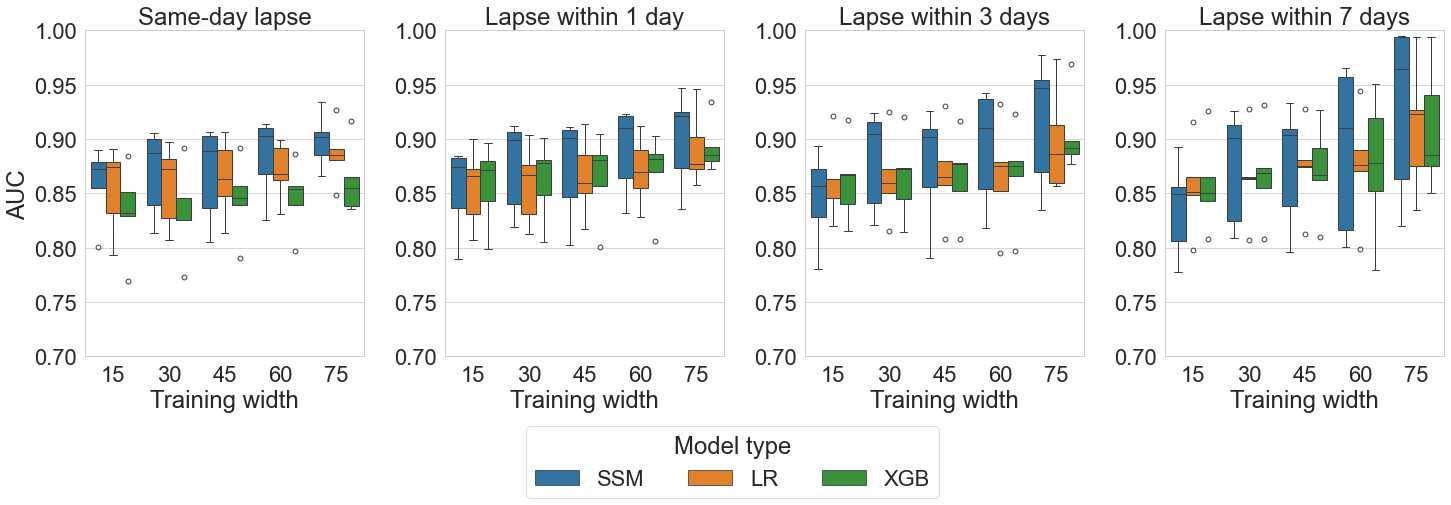

In [23]:
# Prospective version
hue_ord=['SSM','LR','XGB']
#ml_linestyle =  [(1,1),(2,2)]#{"LR":"dashed","XGB":"dotted"}
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    # sns.lineplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',markersize=10,markers = True,linewidth=2,hue_order=hue_ord,ax=ax)
    sns.boxplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',hue_order=hue_ord,ax=ax)
    # sns.stripplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',dodge=True,hue_order=hue_ord,ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    #ax.set_xlim(-5,80)
    ax.set_ylim(0.7,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    #ax.set_xticks(np.arange(0,90,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
#fig.savefig("/Users/eric/repos/aud/plots/paper_plots/ss_ml_auc_data_eff_10.pdf",bbox_inches='tight',facecolor='w')

In [ ]:
# Prospective version
hue_ord=['SSM','LR','XGB']
#ml_linestyle =  [(1,1),(2,2)]#{"LR":"dashed","XGB":"dotted"}
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    # sns.lineplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',markersize=10,markers = True,linewidth=2,hue_order=hue_ord,ax=ax)
    sns.boxplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='aucpr',hue='fit_type',hue_order=hue_ord,ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    #ax.set_xlim(-5,80)
    ax.set_ylim(0,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    #ax.set_xticks(np.arange(0,90,15))
    ax.set_xlabel('Training width')
    if i==0:
        ax.set_ylabel('AUCPR')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
#fig.savefig("plots/paper_plots/ss_ml_auc_rolling_prosp.pdf",bbox_inches='tight',facecolor='w')

In [ ]:
#hue_ord=['MAP_mle','MAP_marss','MLE','MARSS','LR','GB']
#hue_ord=['MAP','MLE','LR','XGB']
eval_df.replace(to_replace='MAP',value='SSM',inplace=True)
#ue_ord=['SSM','LR','XGB']
#hue_ord=['XGB']
pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    nan_val = np.nan
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=ax,native_scale=True)
    sns.lineplot(data=eval_df.query("lapse_prop!=@nan_val & window==@delta"),x='day',y='lapse_prop',linewidth=3,ax=ax)#,native_scale=True)
    ax.set_title(pane_titles[i])
    ax.set_xlim(-5,95)
    ax.set_ylim(0,0.3)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(0,105,15))
    ax.set_xlabel('Day')
    if i==0:
        ax.set_ylabel('Lapse Proportion')
    else:
        ax.set_ylabel('')

#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
#fig.savefig("plots/paper_plots/ss_ml_auc_prospective.pdf",bbox_inches='tight',facecolor='w')

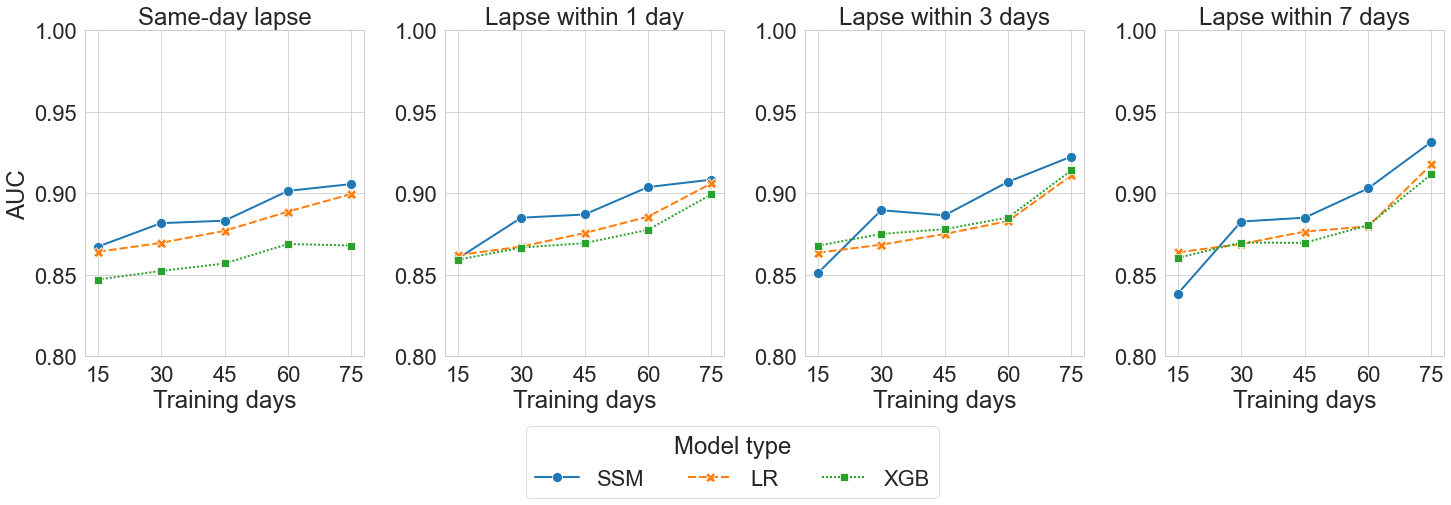

In [15]:
# LOO AUC
hue_ord=['SSM','LR','XGB']

pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    sns.lineplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',markersize=10,markers = True,linewidth=2,hue_order=hue_ord,ax=ax)
    
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    #ax.set_xlim(-5,80)
    ax.set_ylim(0.8,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(15,90,15))
    ax.set_xlabel('Training days')
    if i==0:
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("/Users/eric/repos/aud/plots/paper_plots/ss_ml_auc_loo.pdf",bbox_inches='tight',facecolor='w')

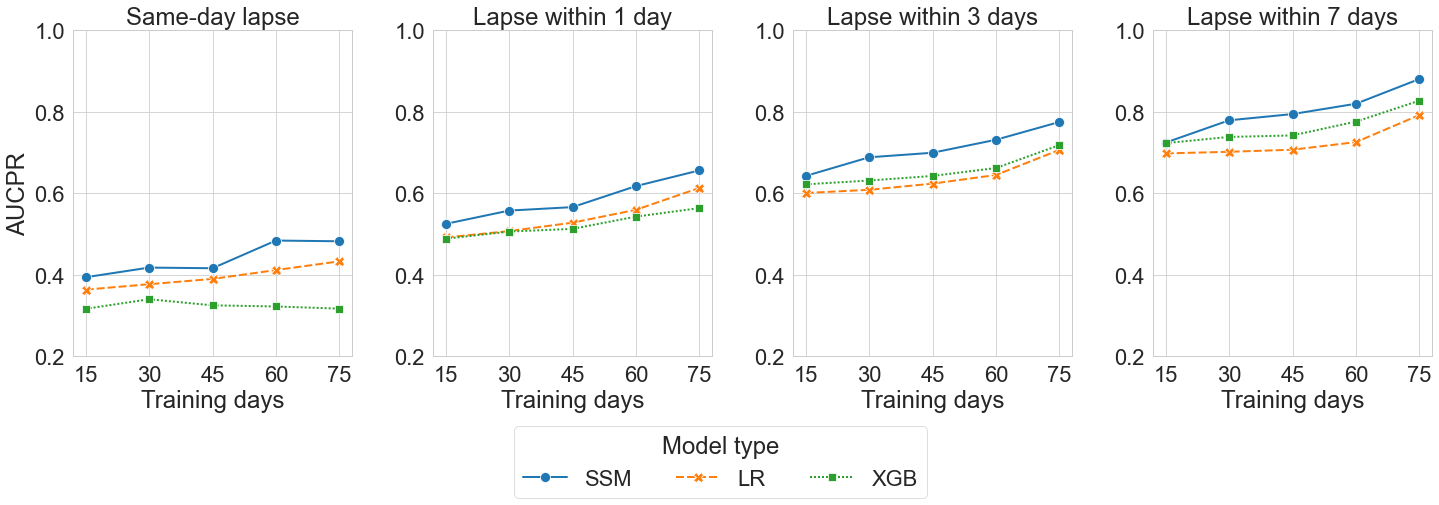

In [16]:
# LOO AUCPR
hue_ord=['SSM','LR','XGB']

pane_titles = ['Same-day lapse', 'Lapse within 1 day', 'Lapse within 3 days','Lapse within 7 days']
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2.5)
fig = plt.figure(figsize=(20,6))
subfigs = fig.subfigures(1,4,wspace=0.05)
limited_palette = sns.color_palette()[1:3]
for i,delta in enumerate(window_delta):
    ax = subfigs[i].subplots()
    sns.lineplot(data=data_eff_eval_df.query("fit_type in @hue_ord & window==@delta"),x='width',y='aucpr',hue='fit_type',style='fit_type',markersize=10,markers = True,linewidth=2,hue_order=hue_ord,ax=ax)
    
    handles, labels = ax.get_legend_handles_labels()
    #sns.lineplot(data=mod_rolling_df.query("fit_type in @ml_mods & window==@delta"),x='width',y='auc',hue='fit_type',style='fit_type',linewidth=2,hue_order=ml_mods,ax=ax,palette=limited_palette,dashes=ml_linestyle)
    ax.set_title(pane_titles[i])
    #ax.set_xlim(-5,80)
    ax.set_ylim(0.2,1.0)
    #ax.set_yticks(np.arange(0.8,1.04,0.04))
    ax.set_xticks(np.arange(15,90,15))
    ax.set_xlabel('Training days')
    if i==0:
        ax.set_ylabel('AUCPR')
    else:
        ax.set_ylabel('')
    if delta==7:
        ax.legend(title='Model type')
        #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),title="Model type")
    else:
        ax.get_legend().remove()
#handles, labels = ax.get_legend_handles_labels()

plt.legend(handles=handles,ncol=4,loc='upper center',title='Model type',bbox_to_anchor=(-1.55,-0.18))
#fig.suptitle('AUC by time step for different prediction windows')
#fig.tight_layout()
fig.savefig("/Users/eric/repos/aud/plots/paper_plots/ss_ml_aucpr_loo.pdf",bbox_inches='tight',facecolor='w')